In [1]:
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
from torch.utils.data import Dataset, DataLoader
from collections import Counter

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
ds = load_dataset("SetFit/ag_news")

train = ds["train"].to_pandas().copy()
test = ds["test"].to_pandas().copy()

test_2000, _ = train_test_split(
    test,
    train_size=2000,
    stratify=test["label"],
    random_state=42,
    shuffle=True
)

train_df, val_df = train_test_split(
    train,
    test_size=0.15,
    stratify=train["label"],
    random_state=42,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_2000 = test_2000.reset_index(drop=True)

print(train_df.shape)
print(val_df.shape)
print(test_2000.shape)
print(test_2000["label"].value_counts())

train.jsonl:   0%|          | 0.00/33.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

(102000, 3)
(18000, 3)
(2000, 3)
label
3    500
2    500
1    500
0    500
Name: count, dtype: int64


In [4]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()


MAX_VOCAB_SIZE = 30000
MAX_LEN = 80
MIN_FREQ = 2

counter = Counter()

for text in train_df["text"]:
    counter.update(tokenize(text))

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, freq in counter.most_common(MAX_VOCAB_SIZE):
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

vocab_size = len(vocab)
vocab_size

30002

In [5]:
def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    if len(ids) < max_len:
        ids += [vocab["<PAD>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

In [6]:
class TextDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN):
        self.texts = df["text"].tolist()
        self.labels = df["label"].astype(int).tolist()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode_text(self.texts[idx], self.vocab, self.max_len)
        y = self.labels[idx]

        return {
            "input_ids": torch.tensor(x, dtype=torch.long),
            "label": torch.tensor(y, dtype=torch.long)
        }

In [7]:
BATCH_SIZE = 64

train_loader = DataLoader(
    TextDataset(train_df, vocab),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TextDataset(val_df, vocab),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TextDataset(test_2000, vocab),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [8]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        num_layers=1,
        dropout=0.3,
        pad_idx=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        output, (hidden, cell) = self.rnn(x)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        h = torch.cat((forward_hidden, backward_hidden), dim=1)
        h = self.dropout(h)

        return self.fc(h)

In [9]:
class BiGRUClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        num_layers=1,
        dropout=0.3,
        pad_idx=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        self.rnn = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        output, hidden = self.rnn(x)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        h = torch.cat((forward_hidden, backward_hidden), dim=1)
        h = self.dropout(h)

        return self.fc(h)

In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [11]:
def evaluate(model, loader, criterion=None):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids)

            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    avg_loss = total_loss / len(loader) if criterion is not None else None

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "labels": all_labels,
        "preds": all_preds
    }

In [12]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_f1 = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_metrics = evaluate(model, val_loader, criterion)

        print(
            f"Epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['f1_macro']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_state = model.state_dict()

    model.load_state_dict(best_state)

    return model

In [13]:
NUM_CLASSES = train_df["label"].nunique()

bilstm_model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=128,
    num_classes=NUM_CLASSES,
    num_layers=1,
    dropout=0.3
)

bilstm_model = train_model(
    bilstm_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-3
)

Epoch 1/5 | train_loss=0.5074 | val_loss=0.3214 | val_acc=0.8951 | val_f1=0.8947
Epoch 2/5 | train_loss=0.2607 | val_loss=0.2722 | val_acc=0.9108 | val_f1=0.9108
Epoch 3/5 | train_loss=0.1929 | val_loss=0.2777 | val_acc=0.9106 | val_f1=0.9107
Epoch 4/5 | train_loss=0.1475 | val_loss=0.2667 | val_acc=0.9134 | val_f1=0.9134
Epoch 5/5 | train_loss=0.1135 | val_loss=0.2841 | val_acc=0.9167 | val_f1=0.9166


In [14]:
bigru_model = BiGRUClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=128,
    num_classes=NUM_CLASSES,
    num_layers=1,
    dropout=0.3
)

bigru_model = train_model(
    bigru_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-3
)

Epoch 1/5 | train_loss=0.4834 | val_loss=0.2877 | val_acc=0.9001 | val_f1=0.9002
Epoch 2/5 | train_loss=0.2435 | val_loss=0.2652 | val_acc=0.9095 | val_f1=0.9092
Epoch 3/5 | train_loss=0.1766 | val_loss=0.2538 | val_acc=0.9159 | val_f1=0.9157
Epoch 4/5 | train_loss=0.1282 | val_loss=0.2726 | val_acc=0.9137 | val_f1=0.9135
Epoch 5/5 | train_loss=0.0904 | val_loss=0.2993 | val_acc=0.9126 | val_f1=0.9127


In [15]:
target_names = ["World", "Sports", "Business", "Sci/Tech"]

def final_test_report(model, test_loader, model_name):
    criterion = nn.CrossEntropyLoss()
    metrics = evaluate(model, test_loader, criterion)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision_macro']:.4f}")
    print(f"Recall:    {metrics['recall_macro']:.4f}")
    print(f"F1-macro:  {metrics['f1_macro']:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            metrics["labels"],
            metrics["preds"],
            target_names=target_names,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(metrics["labels"], metrics["preds"])

    print("Confusion matrix:")
    print(cm)

    return {
        "model": model_name,
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "confusion_matrix": cm
    }

In [16]:
bilstm_results = final_test_report(
    bilstm_model,
    test_loader,
    "BiLSTM"
)

bigru_results = final_test_report(
    bigru_model,
    test_loader,
    "BiGRU"
)

BiLSTM
Accuracy:  0.9050
Precision: 0.9051
Recall:    0.9050
F1-macro:  0.9047

Classification report:
              precision    recall  f1-score   support

       World     0.9277    0.8980    0.9126       500
      Sports     0.9496    0.9800    0.9646       500
    Business     0.8826    0.8420    0.8618       500
    Sci/Tech     0.8604    0.9000    0.8798       500

    accuracy                         0.9050      2000
   macro avg     0.9051    0.9050    0.9047      2000
weighted avg     0.9051    0.9050    0.9047      2000

Confusion matrix:
[[449  12  22  17]
 [  6 490   1   3]
 [ 15  11 421  53]
 [ 14   3  33 450]]
BiGRU
Accuracy:  0.9065
Precision: 0.9067
Recall:    0.9065
F1-macro:  0.9065

Classification report:
              precision    recall  f1-score   support

       World     0.9111    0.9020    0.9065       500
      Sports     0.9581    0.9600    0.9590       500
    Business     0.8652    0.8860    0.8755       500
    Sci/Tech     0.8923    0.8780    0.8851     

In [17]:
results_df = pd.DataFrame([
    {
        "model": bilstm_results["model"],
        "accuracy": bilstm_results["accuracy"],
        "precision_macro": bilstm_results["precision_macro"],
        "recall_macro": bilstm_results["recall_macro"],
        "f1_macro": bilstm_results["f1_macro"]
    },
    {
        "model": bigru_results["model"],
        "accuracy": bigru_results["accuracy"],
        "precision_macro": bigru_results["precision_macro"],
        "recall_macro": bigru_results["recall_macro"],
        "f1_macro": bigru_results["f1_macro"]
    }
])

results_df

,model,accuracy,precision_macro,recall_macro,f1_macro
0,BiLSTM,0.9050,0.905080,0.9050,0.904689
1,BiGRU,0.9065,0.906676,0.9065,0.906537


In [18]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=target_names,
        yticklabels=target_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

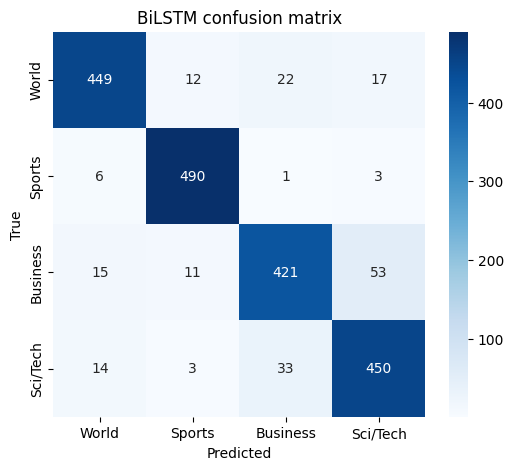

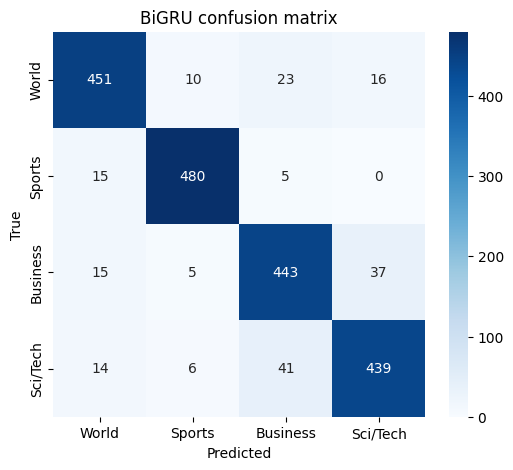

In [19]:
plot_confusion_matrix(
    bilstm_results["confusion_matrix"],
    "BiLSTM confusion matrix"
)

plot_confusion_matrix(
    bigru_results["confusion_matrix"],
    "BiGRU confusion matrix"
)